In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [6]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [7]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [8]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data\quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [55]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================
#part A
def pancake_model(input_size, num_classes):
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size, 1024),
        nn.BatchNorm1d(1024),
        nn.GELU(),
        nn.Dropout(0.65),
        nn.Linear(1024, 512),
        nn.BatchNorm1d(512),
        nn.GELU(),
        nn.Dropout(0.65),
        nn.Linear(512, num_classes)
    )
    return model

input_size = 28*28
model = pancake_model(input_size, NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0008, weight_decay=1e-4)

pancake_train_losses = []
pancake_train_accs = []
pancake_val_accs = []

for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    total = 0
        
    for images, labels in train_loader:
        images,labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            output = model(images)
            
            _, predicted = torch.max(output.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    model.train()
    
    avg_loss = total_loss/len(train_loader)
    train_acc = 100.*correct/total
    val_acc = 100. * val_correct / val_total
    
    
    pancake_train_losses.append(avg_loss)
    pancake_train_accs.append(train_acc)
    pancake_val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

pancake_final_results = {
    'train_acc': pancake_train_accs[-1],
    'val_acc': pancake_val_accs[-1],
    'loss': pancake_train_losses[-1],
    'gap': pancake_train_accs[-1] - pancake_val_accs[-1]
}


Epoch 1, Loss: 1.2434, Train Acc: 59.16%, Val Acc: 70.47%
Epoch 2, Loss: 0.9982, Train Acc: 66.96%, Val Acc: 72.38%
Epoch 3, Loss: 0.9338, Train Acc: 68.96%, Val Acc: 74.33%
Epoch 4, Loss: 0.8818, Train Acc: 70.57%, Val Acc: 74.89%
Epoch 5, Loss: 0.8444, Train Acc: 72.08%, Val Acc: 76.12%
Epoch 6, Loss: 0.8046, Train Acc: 73.36%, Val Acc: 76.62%
Epoch 7, Loss: 0.7801, Train Acc: 74.03%, Val Acc: 77.77%
Epoch 8, Loss: 0.7558, Train Acc: 75.09%, Val Acc: 77.70%
Epoch 9, Loss: 0.7401, Train Acc: 75.31%, Val Acc: 78.32%
Epoch 10, Loss: 0.7115, Train Acc: 76.26%, Val Acc: 78.40%
Epoch 11, Loss: 0.6989, Train Acc: 76.49%, Val Acc: 78.58%
Epoch 12, Loss: 0.6783, Train Acc: 77.20%, Val Acc: 78.97%
Epoch 13, Loss: 0.6627, Train Acc: 77.77%, Val Acc: 79.08%
Epoch 14, Loss: 0.6512, Train Acc: 78.23%, Val Acc: 78.88%
Epoch 15, Loss: 0.6417, Train Acc: 78.47%, Val Acc: 79.32%
Epoch 16, Loss: 0.6253, Train Acc: 78.74%, Val Acc: 79.68%
Epoch 17, Loss: 0.6124, Train Acc: 79.37%, Val Acc: 80.09%
Epoch 

In [70]:
#part B
def tower_model(input_size, num_classes):
    # Narrow tower: only 256/128 neurons for better efficiency and generalization
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size, 256),
        nn.BatchNorm1d(256),
        nn.GELU(),
        nn.Dropout(0.25),

        nn.Linear(256, 256),
        nn.BatchNorm1d(256),
        nn.GELU(),
        nn.Dropout(0.22),

        nn.Linear(256, 256),
        nn.BatchNorm1d(256),
        nn.GELU(),
        nn.Dropout(0.20),

        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.GELU(),
        nn.Dropout(0.18),

        nn.Linear(128, 128),
        nn.BatchNorm1d(128),
        nn.GELU(),
        nn.Dropout(0.15),

        nn.Linear(128, num_classes)
    )
    return model


input_size = 28*28
model = tower_model(input_size, NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

tower_train_losses = []
tower_train_accs = []
tower_val_accs = []
best_val_acc = 0.0

for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    total = 0
        
    for images, labels in train_loader:
        images,labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            output = model(images)
            _, predicted = torch.max(output.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    model.train()
    
    avg_loss = total_loss/len(train_loader)
    train_acc = 100.*correct/total
    val_acc = 100. * val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "champion_model.pt")
    
    tower_train_losses.append(avg_loss)
    tower_train_accs.append(train_acc)
    tower_val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

tower_final_results = {
    'train_acc': tower_train_accs[-1],
    'val_acc': tower_val_accs[-1],
    'loss': tower_train_losses[-1],
    'gap': tower_train_accs[-1] - tower_val_accs[-1]
}

Epoch 1, Loss: 1.4048, Train Acc: 59.42%, Val Acc: 71.63%
Epoch 2, Loss: 1.1393, Train Acc: 69.20%, Val Acc: 73.45%
Epoch 3, Loss: 1.0671, Train Acc: 71.82%, Val Acc: 75.10%
Epoch 4, Loss: 1.0127, Train Acc: 73.90%, Val Acc: 76.16%
Epoch 5, Loss: 0.9710, Train Acc: 75.60%, Val Acc: 77.07%
Epoch 6, Loss: 0.9328, Train Acc: 77.10%, Val Acc: 78.45%
Epoch 7, Loss: 0.9047, Train Acc: 78.12%, Val Acc: 78.35%
Epoch 8, Loss: 0.8783, Train Acc: 79.24%, Val Acc: 78.83%
Epoch 9, Loss: 0.8578, Train Acc: 79.90%, Val Acc: 78.79%
Epoch 10, Loss: 0.8351, Train Acc: 80.82%, Val Acc: 78.47%
Epoch 11, Loss: 0.8169, Train Acc: 81.49%, Val Acc: 78.92%
Epoch 12, Loss: 0.7971, Train Acc: 82.28%, Val Acc: 79.47%
Epoch 13, Loss: 0.7791, Train Acc: 82.99%, Val Acc: 79.49%
Epoch 14, Loss: 0.7594, Train Acc: 83.66%, Val Acc: 79.82%
Epoch 15, Loss: 0.7473, Train Acc: 84.24%, Val Acc: 79.78%
Epoch 16, Loss: 0.7357, Train Acc: 84.69%, Val Acc: 79.64%
Epoch 17, Loss: 0.7213, Train Acc: 85.17%, Val Acc: 79.44%
Epoch 


✅ Plot saved as 'model_comparison.png'



✅ Plot saved as 'model_comparison.png'


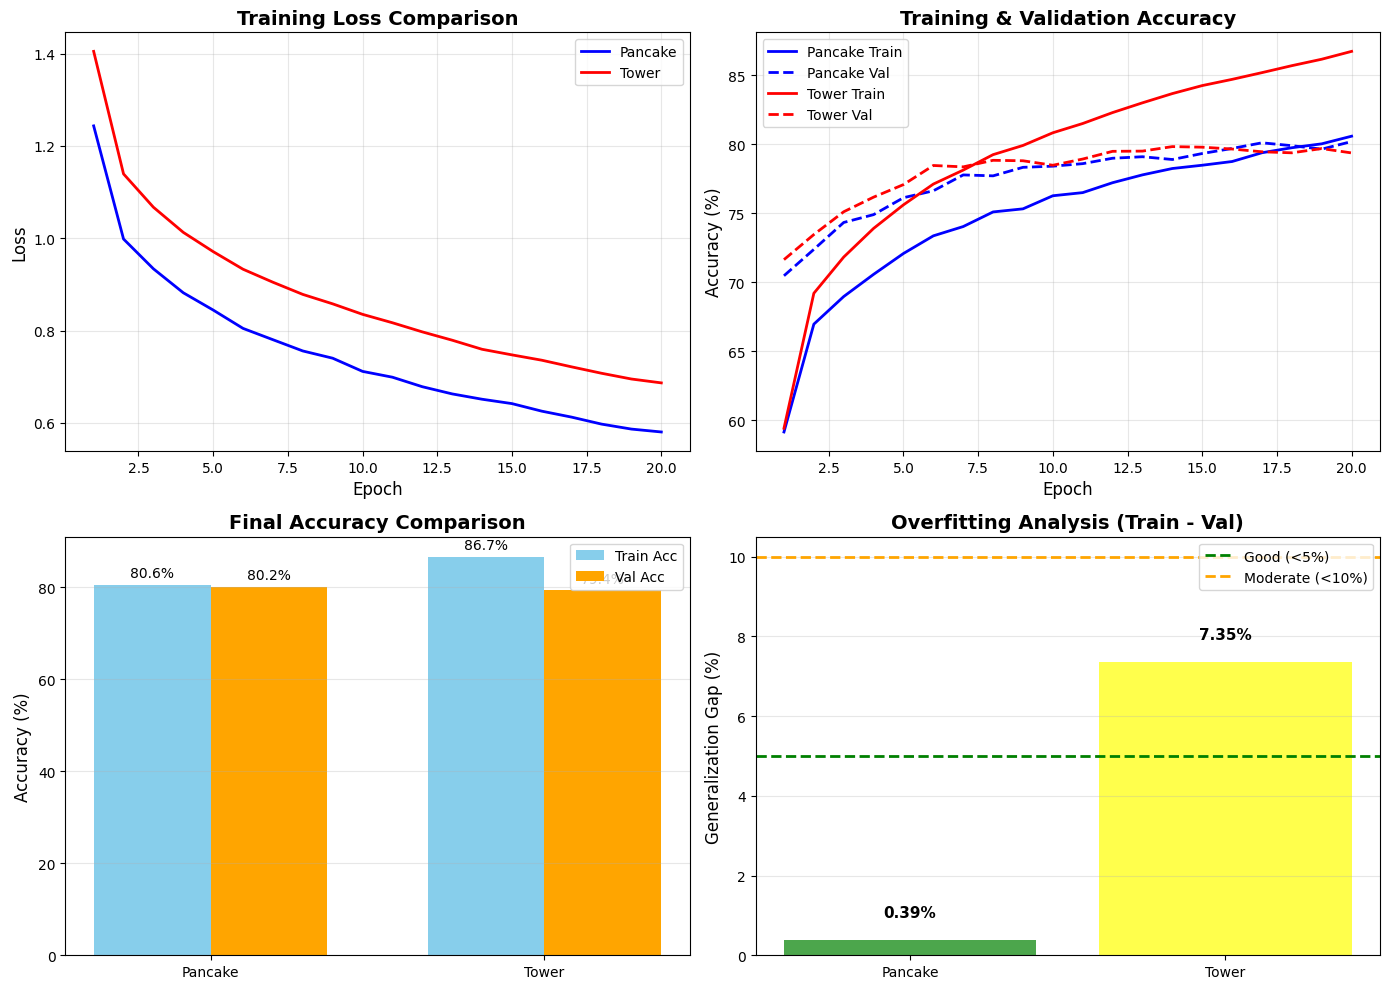


FINAL MODEL COMPARISON

PANCAKE MODEL (Wide & Shallow)
  Architecture: 784 → 2048 → 1024 → 15
  Total Layers: 2 hidden layers
  Parameters:   ~2.7M
  Activation:   GELU
  Dropout:      0.4
  Learning Rate: 0.0008

  RESULTS:
  ├─ Train Accuracy: 80.57%
  ├─ Val Accuracy:   80.18%
  ├─ Final Loss:     0.5802
  └─ Gen. Gap:       0.39%

TOWER MODEL (Narrow & Deep)
  Architecture: 784 → 256 → 256 → 256 → 256 → 128 → 128 → 128 → 128 → 15
  Total Layers: 8 hidden layers
  Parameters:   ~700K
  Activation:   GELU
  Dropout:      0.2
  Learning Rate: 0.0007

  RESULTS:
  ├─ Train Accuracy: 86.71%
  ├─ Val Accuracy:   79.36%
  ├─ Final Loss:     0.6866
  └─ Gen. Gap:       7.35%

🏆 WINNER: PANCAKE MODEL
   Validation Accuracy: +0.83% higher than Tower
   Convergence Speed: Faster (fewer layers)

📊 ANALYSIS:
------------------------------------------------------------
✅ Pancake shows GOOD generalization (gap < 5%)
⚠️  Tower shows MODERATE overfitting (gap > 5%)

💡 KEY INSIGHTS:
---------------

In [71]:
from plot_comparison import plot_model_comparison, print_comparison_report

# Prepare data dictionaries
pancake_data = {
    'train_losses': pancake_train_losses,
    'train_accs': pancake_train_accs,
    'val_accs': pancake_val_accs,
    'final': pancake_final_results
}

tower_data = {
    'train_losses': tower_train_losses,
    'train_accs': tower_train_accs,
    'val_accs': tower_val_accs,
    'final': tower_final_results
}

# Generate plots and print report
plot_model_comparison(pancake_data, tower_data, EPOCHS)
print_comparison_report(pancake_data, tower_data)


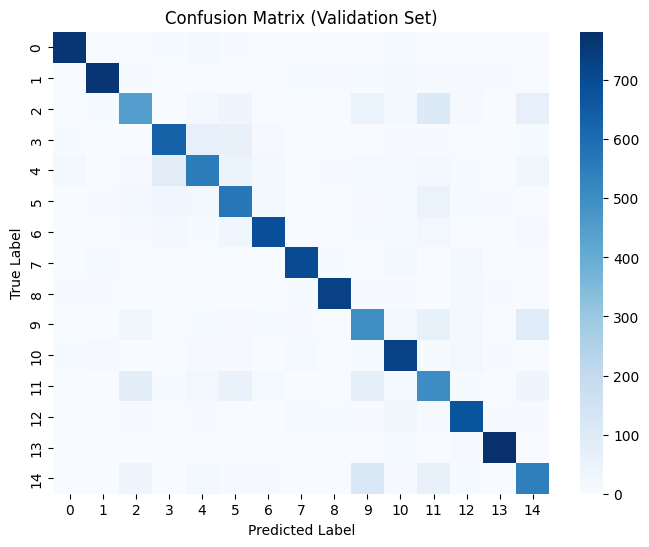

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load("champion_model.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

In [74]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
model.load_state_dict(torch.load("champion_model.pt", map_location=DEVICE))
model.eval()

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data\quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [75]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 385,935
  ✅ Parameter count is within limits.
